# Predicción de resultados de fútbol — EDA e Ingeniería de Variables

Este cuaderno cubre las dos primeras fases del pipeline:
1. Análisis exploratorio del conjunto de datos base (`train.csv`)
2. Construcción del conjunto de datos enriquecido con variables temporales

Los módulos auxiliares (`features/`, `datasources/`) contienen las implementaciones reutilizadas en los cuadernos siguientes.

In [10]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasources.csv_source import CSVSource

df_raw = CSVSource(path=Path("data/raw/train.csv")).load()
df_raw["fecha"] = pd.to_datetime(df_raw["fecha"])
print(f"Partidos: {len(df_raw)}  |  Columnas: {list(df_raw.columns)}")
df_raw.head()

Partidos: 17480  |  Columnas: ['id', 'division', 'anio_fin_temporada', 'fecha', 'local', 'visitante', 'goles_local', 'goles_visitante', 'resultado']


,id,division,anio_fin_temporada,fecha,local,visitante,goles_local,goles_visitante,resultado
0,10341_2223_ESP1,ESP_LaLiga,2023,2023-06-04,Espanol,Almeria,3,3,X_empate
1,10334_2223_ESP1,ESP_LaLiga,2023,2023-06-04,Osasuna,Girona,2,1,1_local
2,10335_2223_ESP1,ESP_LaLiga,2023,2023-06-04,Real Madrid,Ath Bilbao,1,1,X_empate
3,10336_2223_ESP1,ESP_LaLiga,2023,2023-06-04,Sociedad,Sevilla,2,1,1_local
4,10337_2223_ESP1,ESP_LaLiga,2023,2023-06-04,Villarreal,Ath Madrid,2,2,X_empate


## 1. Exploración inicial

Revisamos la distribución de resultados por liga y temporada para entender el balance de clases y detectar posibles sesgos.

In [11]:
print("=== Distribución global de resultados ===")
print(df_raw["resultado"].value_counts(normalize=True).round(3))

print("\n=== Partidos por liga ===")
print(df_raw["division"].value_counts())

print("\n=== Temporadas disponibles ===")
print(sorted(df_raw["anio_fin_temporada"].unique()))

=== Distribución global de resultados ===
resultado
1_local        0.466
2_visitante    0.284
X_empate       0.250
Name: proportion, dtype: float64

=== Partidos por liga ===
division
ESP_LaLiga     8740
ENG_Premier    8740
Name: count, dtype: int64

=== Temporadas disponibles ===
[np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


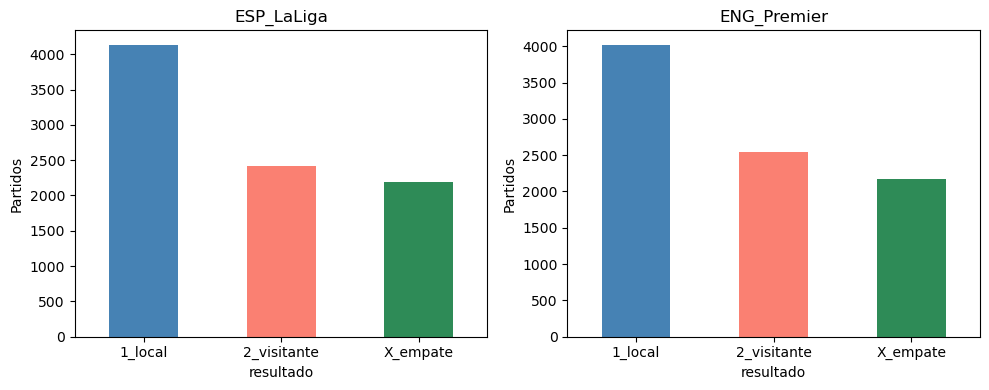

In [12]:
# Distribución de resultados por liga
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, liga in zip(axes, ["ESP_LaLiga", "ENG_Premier"]):
    counts = df_raw[df_raw["division"] == liga]["resultado"].value_counts()
    counts.plot(kind="bar", ax=ax, title=liga, rot=0, color=["steelblue", "salmon", "seagreen"])
    ax.set_ylabel("Partidos")
plt.tight_layout()
plt.show()

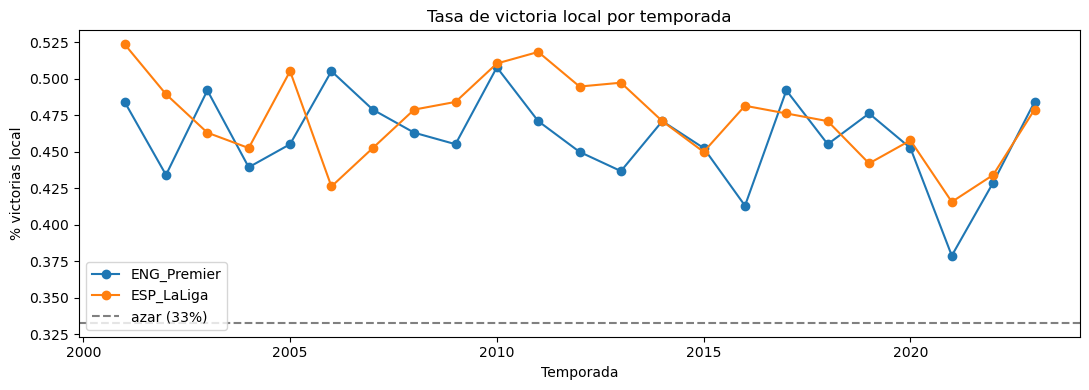

In [13]:
# Evolución del % de victorias locales por temporada
home_win_rate = (
    df_raw.groupby(["anio_fin_temporada", "division"])["resultado"]
    .apply(lambda x: (x == "1_local").mean())
    .reset_index(name="home_win_rate")
)

fig, ax = plt.subplots(figsize=(11, 4))
for liga, grp in home_win_rate.groupby("division"):
    ax.plot(grp["anio_fin_temporada"], grp["home_win_rate"], marker="o", label=liga)
ax.axhline(0.333, linestyle="--", color="gray", label="azar (33%)")
ax.set_title("Tasa de victoria local por temporada")
ax.set_xlabel("Temporada")
ax.set_ylabel("% victorias local")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Ingeniería de variables temporales

A partir del dataset base (solo resultado de cada partido) construimos un conjunto enriquecido con:

| Grupo | Variables |
|---|---|
| **Calidad acumulada** | puntos, diferencia de goles, posición en tabla |
| **ELO** | rating global + específico local/visitante |
| **Head-to-head** | historial directo entre cada par de equipos |
| **Forma reciente** | últimos N partidos, con y sin separar casa/fuera |
| **Rachas** | victorias consecutivas, partidos sin perder |
| **Presión de temporada** | jornada relativa, zonas de descenso/champions |
| **Condiciones** | días de descanso desde el último partido |
| **Diferencias** | home - away para cada grupo anterior |

Todas las variables están calculadas **solo con información anterior al partido** (anti data leakage).

La forma utiliza rolling cross-season: no se resetea al inicio de temporada, ya que un equipo mantiene su racha entre mayo y agosto.

In [14]:
from features.utils.teams import create_teams_df
from features.internal.calidad import pts, add_calidad
from features.internal.estado import add_estado
from features.internal.condiciones import add_condiciones
from features.internal.elo import add_elo
from features.internal.h2h import add_h2h
from features.internal.presion import add_presion
from features.derived.diferencias import add_diferencias

N_FORM = 5

def build_features(df_liga):
    team_df = create_teams_df(df_liga)
    df = pts(df_liga.copy())
    df = add_elo(df)
    df = add_h2h(df)
    df = add_calidad(df, team_df)
    df = add_estado(df, team_df, n=N_FORM)
    df = add_condiciones(df, team_df)
    df = add_presion(df)
    df = add_diferencias(df, n=N_FORM)
    num_cols = df.select_dtypes(include="number").columns
    for col in num_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    return df

In [15]:
# Construimos features para cada liga por separado
dfs_enriquecidos = {}
for liga in ["ESP_LaLiga", "ENG_Premier"]:
    df_liga = df_raw[df_raw["division"] == liga].copy()
    dfs_enriquecidos[liga] = build_features(df_liga)
    print(f"{liga}: {len(dfs_enriquecidos[liga])} partidos, {dfs_enriquecidos[liga].shape[1]} columnas")

ESP_LaLiga: 8740 partidos, 80 columnas
ENG_Premier: 8740 partidos, 80 columnas


In [16]:
# Vista de las columnas generadas
df_ejemplo = dfs_enriquecidos["ESP_LaLiga"]

FEATURE_COLS = [
    "home_pts_acum", "away_pts_acum", "home_gd_acum", "away_gd_acum",
    "home_posicion", "away_posicion",
    f"home_pts_N{N_FORM}", f"away_pts_N{N_FORM}",
    "home_elo", "away_elo", "diff_elo",
    "h2h_n", "h2h_win_local", "h2h_win_visit",
    "jornada_ratio", "home_zona_descenso", "away_zona_champions",
    f"home_pts_N{N_FORM}_home", f"away_pts_N{N_FORM}_away",
]

print("Muestra del dataset enriquecido (últimas 5 filas, features clave):")
df_ejemplo[FEATURE_COLS + ["resultado"]].tail(5)

Muestra del dataset enriquecido (últimas 5 filas, features clave):


,home_pts_acum,away_pts_acum,home_gd_acum,away_gd_acum,home_posicion,away_posicion,home_pts_N5,away_pts_N5,home_elo,away_elo,diff_elo,h2h_n,h2h_win_local,h2h_win_visit,jornada_ratio,home_zona_descenso,away_zona_champions,home_pts_N5_home,away_pts_N5_away,resultado
8735,24,41,-37,-23,20,15,8.0,6.0,1442.349055,1515.879637,-73.530582,5,0.400000,0.200000,1.0,1,0,7.0,4.0,X_empate
8736,47,49,-9,-5,12,10,6.0,6.0,1512.525575,1515.808793,-3.283217,13,0.615385,0.153846,1.0,0,0,11.0,1.0,1_local
8737,39,41,-30,-11,18,14,4.0,10.0,1474.653711,1515.885281,-41.231570,17,0.411765,0.235294,1.0,1,0,7.0,3.0,X_empate
8738,40,88,-11,51,16,1,1.0,9.0,1502.331458,1772.703098,-270.371640,33,0.242424,0.484848,1.0,0,1,5.0,7.0,1_local
8739,36,40,-17,-16,19,17,5.0,7.0,1482.021546,1465.869677,16.151869,13,0.384615,0.384615,1.0,1,0,5.0,3.0,X_empate


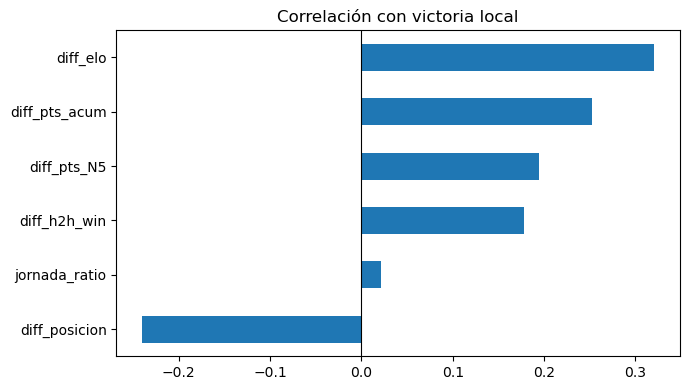

In [17]:
# Correlación de algunas variables con victoria local (1_local)
df_corr = df_ejemplo.copy()
df_corr["es_local"] = (df_corr["resultado"] == "1_local").astype(int)

vars_interes = ["diff_elo", "diff_pts_acum", "diff_posicion",
                f"diff_pts_N{N_FORM}", "diff_h2h_win", "jornada_ratio"]
corrs = df_corr[vars_interes + ["es_local"]].corr()["es_local"].drop("es_local").sort_values()

corrs.plot(kind="barh", figsize=(7, 4), title="Correlación con victoria local")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 3. Comprobación anti data leakage

Verificamos que ninguna feature del partido t usa información generada después de t.

In [18]:
# El ELO y el rolling usan shift(1), por lo que el primer partido de un equipo
# tiene valor 0 / mediana de la liga (cold start), nunca el resultado propio.
# Comprobamos que h2h_n para el primer enfrentamiento entre dos equipos es 0.

primeros = df_ejemplo.sort_values("fecha").groupby(["local", "visitante"]).first().reset_index()
print("h2h_n en el primer enfrentamiento de cada par:")
print(primeros["h2h_n"].value_counts())
# Todos deben ser 0

h2h_n en el primer enfrentamiento de cada par:
h2h_n
0    682
1    682
Name: count, dtype: int64
